In [1]:
import numpy as np
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=100)

Question 1:

In [2]:
grid = []

k = 1

while k <= 7:
    grid.append(k/7)
    k += 1

grid = np.array(grid)      

draws = rng.choice(grid, size = 5000)


<Axes: ylabel='Proportion'>

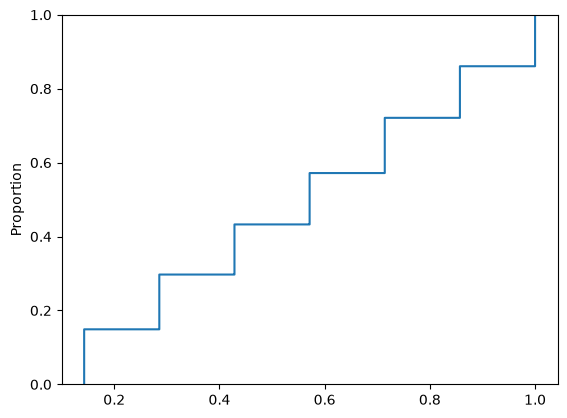

In [3]:
sns.ecdfplot(draws)

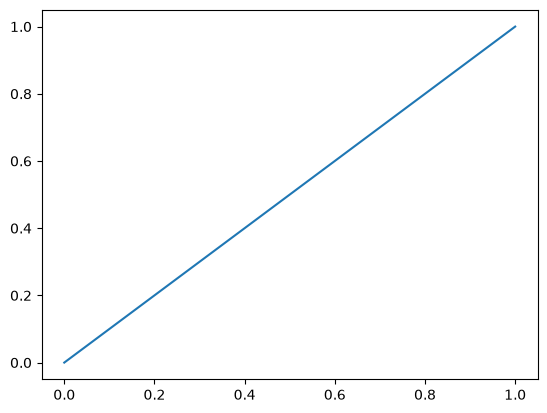

In [4]:
from scipy.stats import uniform

#As K increases
x = np.linspace(0, 1, 100)

plt.plot(x, uniform.cdf(x, loc=0, scale=1))
plt.show()

As K increases, there will be more steps, causing the line to flatten out and resemble the normal distribution.

Question 3:


In [ ]:
results = ['H', 'T']

flips = rng.choice(results, size=40)

heads = (flips == 'H').sum()
print(heads)

np.int64(22)

In [ ]:
z = (heads - 40*0.5) / np.sqrt(40*0.5*(1-0.5))
print(z)

np.float64(0.6324555320336759)

<Axes: ylabel='Proportion'>

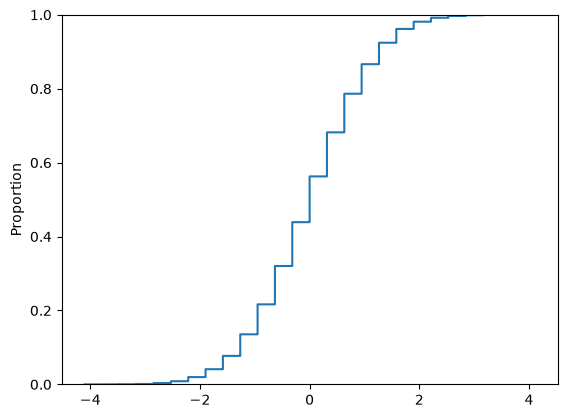

In [29]:
z_list = []
B = 50000

for i in range(B):
    flips = rng.choice(results, size=40)
    heads = (flips == 'H').sum()

    z = (heads - 40*0.5) / np.sqrt(40*0.5*(1-0.5))

    z_list.append(z)

sns.ecdfplot(z_list)


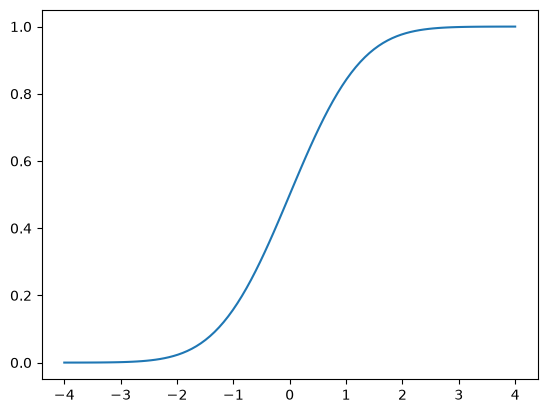

In [34]:
from scipy.stats import norm
x= np.linspace(-4,4,100)
plt.plot(x, norm.cdf(x, loc=0, scale=1))

This simulation generates the normal distribution cdf as n increases.

<Axes: ylabel='Proportion'>

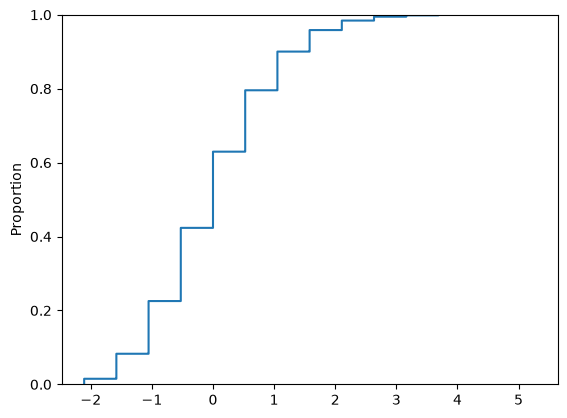

In [95]:
z_list = []
B = 50000
p = .1

for i in range(B):
    flips = rng.choice(results, size=40, p=[p, 1-p])
    heads = (flips == 'H').sum()

    z = (heads - 40*p) / np.sqrt(40*p*(1-p))

    z_list.append(z)

sns.ecdfplot(z_list)

As p increases, the inflection point shifts to the right and as p decreases, the inflection point shifts to the left.

Question 5:

In [45]:
values = rng.random(size = 20)
values_sorted = sorted(values)
maximum = values_sorted[19]
print(maximum)


0.9911867873988763


<Axes: ylabel='Proportion'>

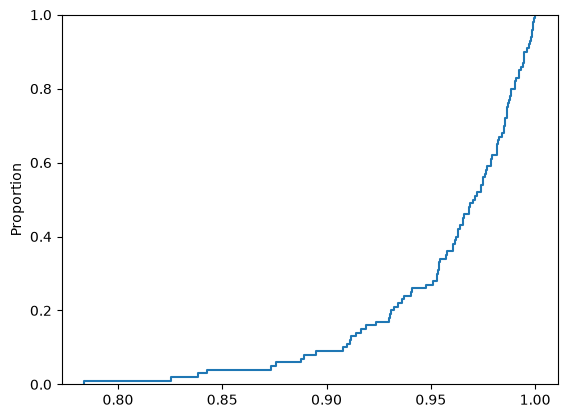

In [51]:
#Repeat n times
maximums_list = []
for i in range(100):
    values = rng.random(size = 20)
    values_sorted = sorted(values)
    maximum = values_sorted[19]
    maximums_list.append(maximum)

sns.ecdfplot(maximums_list)

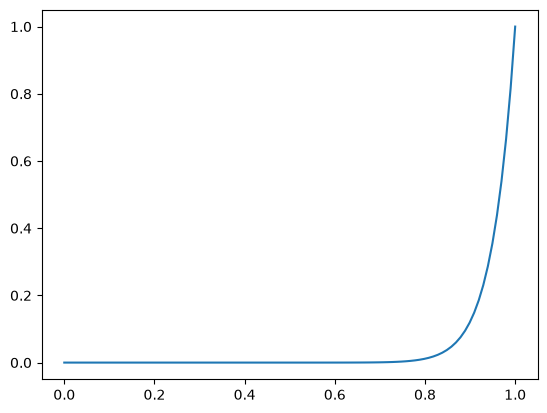

In [57]:
from scipy.stats import beta
x= np.linspace(0,1,100)
plt.plot(x, beta.cdf(x, 20, 1))

The above trial represents the beta distribution cdf.

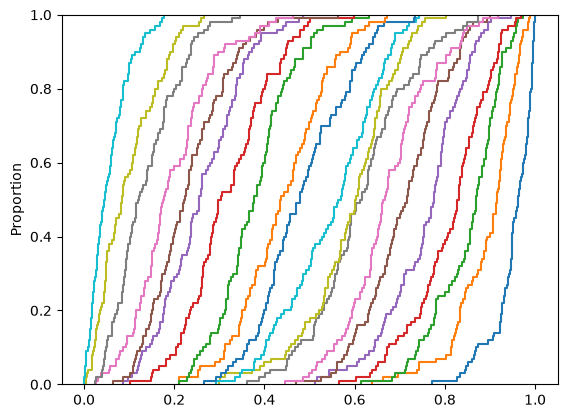

In [54]:
k = 19

while k >= 0:
    rank_list = []

    for i in range(100):
        values = rng.random(size=20)
        values_sorted = sorted(values)

        rank_value = values_sorted[k]
        rank_list.append(rank_value)

    sns.ecdfplot(rank_list)

    k -= 1


This graph seems to shift distribution family as the rank increases from low to high. On the left, the plots look like pareto distributions. As you move towards the center, the plots look normally distributed, and to right, the plots look like beta distributions.

Question 7:

In [64]:
k = 100000
ranks = range(1, k + 1)

In [66]:
sizes = []
s = 1
for rank in ranks:
    size = (k / rank)**s
    sizes.append(size)

<Axes: ylabel='Proportion'>

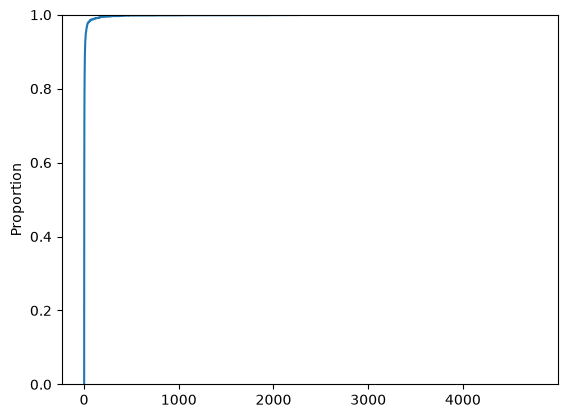

In [73]:
sizes_sample = rng.choice(sizes, 5000)

sns.ecdfplot(sizes_sample)

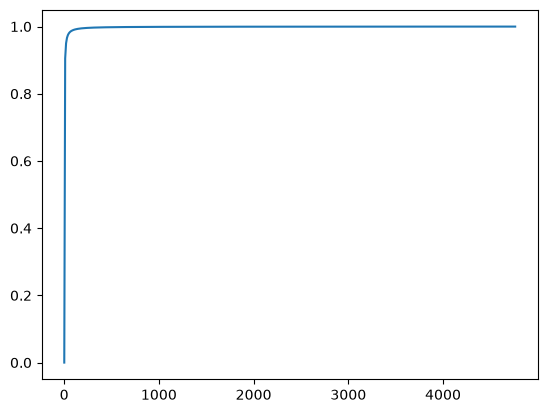

In [77]:
from scipy.stats import pareto, expon

x = np.linspace(1, max(sizes_sample), 500)
plt.plot(x, pareto.cdf(x, b=1, scale=1))

As k becomes large, this generates the pareto distribution.

<Axes: ylabel='Proportion'>

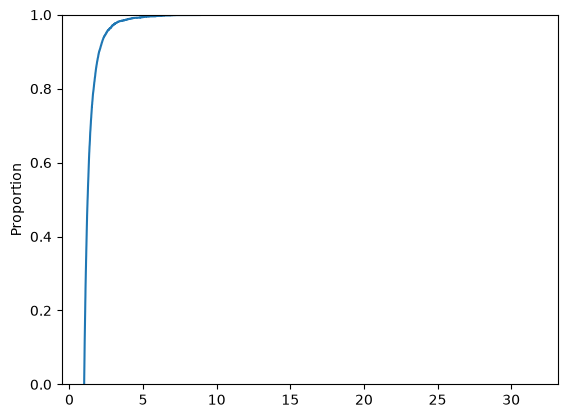

In [89]:
sizes = []
s = .3
for rank in ranks:
    size = (k / rank)**s
    sizes.append(size)

sizes_sample = rng.choice(sizes, 5000)

sns.ecdfplot(sizes_sample)

As s decreases, the populations become smaller, as can be seen by the shrinking of the x-axis (population size). The opposite is true as s increases, as the x-axis values grow in size.